In [2]:
!pwd
!ls /content

/content
sample_data


In [3]:
%cd /content
!git clone https://github.com/ankitha24ad002-boop/LungLens.git

/content
Cloning into 'LungLens'...
remote: Enumerating objects: 175, done.
remote: Counting objects: 100% (175/175), done.
remote: Compressing objects: 100% (149/149), done.
remote: Total 175 (delta 55), reused 60 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (175/175), 577.69 KiB | 2.28 MiB/s, done.
Resolving deltas: 100% (55/55), done.


In [4]:
!ls /content

LungLens  sample_data


In [5]:
%cd /content/LungLens

/content/LungLens


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!find . -maxdepth 2

.
./docs
./docs/presentation.pdf
./docs/architecture.png
./.git
./.git/description
./.git/packed-refs
./.git/logs
./.git/info
./.git/refs
./.git/HEAD
./.git/index
./.git/hooks
./.git/branches
./.git/config
./.git/objects
./README.md
./src
./src/utils
./src/data
./src/models
./src/config.py
./models
./models/label_map.json
./models/best_model.pth
./requirements.txt
./api
./api/route.py
./api/main.py
./.gitignore
./notebooks
./notebooks/01_data_exploration.ipynb
./notebooks/02_model_training.ipynb
./notebooks/03_explainability.ipynb
./app
./app/streamlit_app.py


In [8]:
!pip install -r requirements.txt

In [9]:
import os

base = "/content/drive/MyDrive/LungLens/data/processed"

for split in ["train", "val", "test"]:
    print(split)

    for cls in ["BACTERIA", "VIRUS"]:
        folder = os.path.join(base, split, cls)

        print(cls, len(os.listdir(folder)))

train
BACTERIA 4
VIRUS 4
val
BACTERIA 4
VIRUS 4
test
BACTERIA 4
VIRUS 4


In [10]:
import os
import random
import shutil

random.seed(42)

base = "/content/drive/MyDrive/LungLens/data/processed"

classes = ["BACTERIA", "VIRUS"]

for cls in classes:

    train_dir = os.path.join(base, "train", cls)
    val_dir = os.path.join(base, "val", cls)
    test_dir = os.path.join(base, "test", cls)

    os.makedirs(val_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    images = os.listdir(train_dir)
    random.shuffle(images)

    # Move 2 images to validation
    for img in images[:2]:
        shutil.move(
            os.path.join(train_dir, img),
            os.path.join(val_dir, img)
        )

    # Move next 2 images to test
    for img in images[2:4]:
        shutil.move(
            os.path.join(train_dir, img),
            os.path.join(test_dir, img)
        )

print("Dataset split completed!")

Dataset split completed!


In [11]:
import os

base = "/content/drive/MyDrive/LungLens/data/processed"

for split in ["train", "val", "test"]:

    print(f"\n{split.upper()}")

    for cls in ["BACTERIA", "VIRUS"]:

        folder = os.path.join(base, split, cls)

        print(cls, len(os.listdir(folder)))


TRAIN
BACTERIA 0
VIRUS 0

VAL
BACTERIA 6
VIRUS 6

TEST
BACTERIA 6
VIRUS 6


In [12]:
import sys
sys.path.append("/content/LungLens")

from src.data.dataset import LungDataset

print("Dataset imported successfully!")


Dataset imported successfully!


In [13]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [14]:
train_dataset = LungDataset(
    "/content/drive/MyDrive/LungLens/data/processed/train",
    transform=train_transform
)

val_dataset = LungDataset(
    "/content/drive/MyDrive/LungLens/data/processed/val",
    transform=val_transform
)

test_dataset = LungDataset(
    "/content/drive/MyDrive/LungLens/data/processed/test",
    transform=val_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 0
Validation: 12
Test: 12


In [37]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

ValueError: num_samples should be a positive integer value, but got num_samples=0

In [17]:
# ============================
# Install Required Libraries
# ============================

!pip install torch torchvision scikit-learn matplotlib pillow tqdm -q

# ============================
# Imports
# ============================

import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, models

from torch.utils.data import DataLoader

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

from tqdm import tqdm

# Import your dataset class
import sys
sys.path.append("/content/LungLens")

from src.data.dataset import LungDataset

print("All libraries imported successfully!")

All libraries imported successfully!


In [18]:
# ============================
# Dataset Paths
# ============================

TRAIN_DIR = "/content/drive/MyDrive/LungLens/data/processed/train"
VAL_DIR = "/content/drive/MyDrive/LungLens/data/processed/val"
TEST_DIR = "/content/drive/MyDrive/LungLens/data/processed/test"

MODEL_DIR = "/content/LungLens/models"

RESULTS_DIR = "/content/LungLens/results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Folders Ready!")

Folders Ready!


In [19]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

print("Transforms Ready!")

Transforms Ready!


In [20]:
train_dataset = LungDataset(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = LungDataset(
    VAL_DIR,
    transform=val_transform
)

test_dataset = LungDataset(
    TEST_DIR,
    transform=val_transform
)

print("Train Images :", len(train_dataset))
print("Validation Images :", len(val_dataset))
print("Test Images :", len(test_dataset))

Train Images : 0
Validation Images : 12
Test Images : 12


In [35]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)

print("DataLoaders Created!")

ValueError: num_samples should be a positive integer value, but got num_samples=0

In [36]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))

for i in range(4):

    plt.subplot(1,4,i+1)

    img = images[i].permute(1,2,0)

    plt.imshow(img)

    plt.title(train_dataset.classes[labels[i]])

    plt.axis("off")

plt.show()

NameError: name 'train_loader' is not defined

In [28]:
# ============================
# Device
# ============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cuda


In [29]:
# ============================
# Load Pretrained ResNet18
# ============================

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer for 2 classes
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=2, bias=True)


In [30]:
# ============================
# Loss Function
# ============================

criterion = nn.CrossEntropyLoss()

# ============================
# Optimizer
# ============================

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("Loss and Optimizer Ready!")

Loss and Optimizer Ready!


In [31]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [32]:
def validate(model, loader, criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [38]:
NUM_EPOCHS = 10

best_val_loss = float("inf")

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")

    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")

    print(f"Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_acc:.4f}")

    print("-"*50)

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "/content/LungLens/models/best_model.pth"
        )

        print("✅ Best Model Saved!")

NameError: name 'train_loader' is not defined

In [39]:
# ============================
# Load Best Model
# ============================

model.load_state_dict(
    torch.load("/content/LungLens/models/best_model.pth", map_location=device)
)

model.eval()

print("✅ Best model loaded!")

UnpicklingError: Weights only load failed. In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
Please file an issue with the following so that we can make `weights_only=True` compatible with your use case: WeightsUnpickler error: 

Unsupported operand 10

Check the documentation of torch.load to learn more about types accepted by default with weights_only https://pytorch.org/docs/stable/generated/torch.load.html.

In [40]:
# ============================
# Evaluate on Test Set
# ============================

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())

        all_predictions.extend(predicted.cpu().numpy())

print("Testing Complete!")

NameError: name 'test_loader' is not defined

In [41]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(all_labels, all_predictions)

print(f"Test Accuracy: {accuracy*100:.2f}%")

Test Accuracy: nan%


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/tmp/ipykernel_1058/1837117861.py:8: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(cm, interpolation="nearest")
/tmp/ipykernel_1058/1837117861.py:8: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(cm, interpolation="nearest")


IndexError: index 0 is out of bounds for axis 0 with size 0

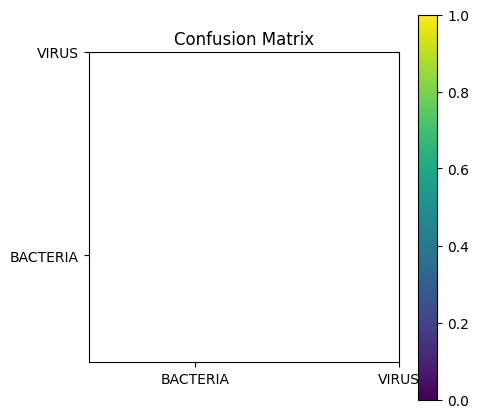

In [42]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(5,5))

plt.imshow(cm, interpolation="nearest")

plt.title("Confusion Matrix")

plt.colorbar()

classes = train_dataset.classes

plt.xticks(range(len(classes)), classes)

plt.yticks(range(len(classes)), classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white"
        )

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("/content/LungLens/results/confusion_matrix.png")

plt.show()

In [45]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_predictions,
    target_names=train_dataset.classes
))

ValueError: Number of classes, 0, does not match size of target_names, 2. Try specifying the labels parameter

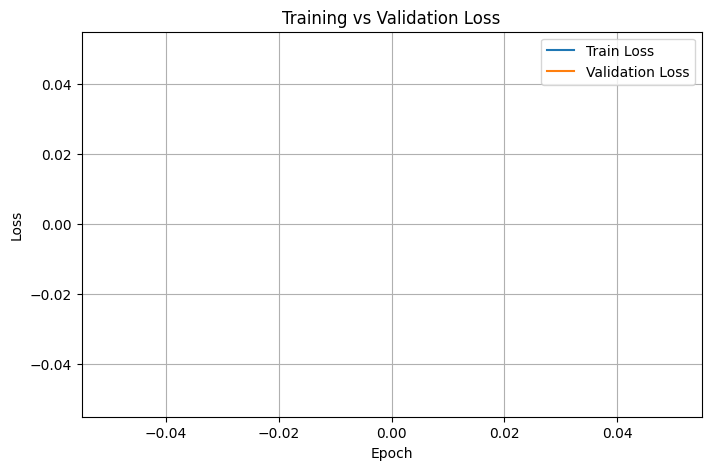

In [43]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")

plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.savefig("/content/LungLens/results/loss_curve.png")

plt.show()

In [46]:
history = {
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_accuracy": train_accs,
    "val_accuracy": val_accs
}

with open("/content/LungLens/results/training_history.json", "w") as f:
    json.dump(history, f, indent=4)

print("✅ Training history saved!")

✅ Training history saved!


In [47]:
label_map = {
    "0": "BACTERIA",
    "1": "VIRUS"
}

with open("/content/LungLens/models/label_map.json", "w") as f:
    json.dump(label_map, f, indent=4)

print("✅ Label map saved!")

✅ Label map saved!


In [48]:
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

print("Evaluation Complete!")

NameError: name 'test_loader' is not defined

In [49]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(all_labels, all_predictions)

print(f"Test Accuracy : {accuracy*100:.2f}%")

Test Accuracy : nan%


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [50]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_predictions,
    target_names=train_dataset.classes
))

ValueError: Number of classes, 0, does not match size of target_names, 2. Try specifying the labels parameter

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_predictions)

fig, ax = plt.subplots(figsize=(5,5))

im = ax.imshow(cm)

ax.set_xticks([0,1])
ax.set_xticklabels(train_dataset.classes)

ax.set_yticks([0,1])
ax.set_yticklabels(train_dataset.classes)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j],
                ha="center",
                va="center",
                color="white",
                fontsize=14)

plt.savefig("/content/LungLens/results/confusion_matrix.png")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.savefig("/content/LungLens/results/loss_curve.png")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_accs, label="Training Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.savefig("/content/LungLens/results/accuracy_curve.png")

plt.show()

In [ ]:
history = {
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_accuracy": train_accs,
    "val_accuracy": val_accs
}

import json

with open("/content/LungLens/results/training_history.json","w") as f:
    json.dump(history,f,indent=4)

print("Training history saved.")

In [24]:
from src.models.predict import predict_image

result = predict_image(
    "/content/drive/MyDrive/LungLens/data/processed/test/BACTERIA/BACTERIA-7.jpeg"
)

print(result)

UnpicklingError: Weights only load failed. In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
Please file an issue with the following so that we can make `weights_only=True` compatible with your use case: WeightsUnpickler error: 

Unsupported operand 10

Check the documentation of torch.load to learn more about types accepted by default with weights_only https://pytorch.org/docs/stable/generated/torch.load.html.

In [23]:
import os

model_path = "/content/LungLens/models/best_model.pth"

print(os.path.exists(model_path))
print(os.path.getsize(model_path))

True
1


In [51]:
import os

for root, dirs, files in os.walk("/content"):
    if "best_model.pth" in files:
        path = os.path.join(root, "best_model.pth")
        print(path)
        print("Size:", os.path.getsize(path), "bytes")
        print("-" * 40)

/content/LungLens/models/best_model.pth
Size: 1 bytes
----------------------------------------


In [52]:
torch.save(
    model.state_dict(),
    "/content/LungLens/models/best_model.pth"
)

In [53]:
print(type(model))
print(model)

<class 'torchvision.models.resnet.ResNet'>
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stat

In [54]:
import os

model_path = "/content/LungLens/models/best_model.pth"

if os.path.exists(model_path):
    os.remove(model_path)

print("Old file deleted.")

Old file deleted.


In [55]:
import torch

torch.save(model.state_dict(), "/content/LungLens/models/best_model.pth")

print("Model saved successfully!")

Model saved successfully!


In [56]:
import os

size = os.path.getsize("/content/LungLens/models/best_model.pth")

print(size)

44789771


In [57]:
new_model = models.resnet18(weights=None)
new_model.fc = nn.Linear(new_model.fc.in_features, 2)

new_model.load_state_dict(
    torch.load(
        "/content/LungLens/models/best_model.pth",
        map_location="cpu"
    )
)

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [58]:
import shutil
import os

os.makedirs("/content/drive/MyDrive/LungLens/models", exist_ok=True)

shutil.copy(
    "/content/LungLens/models/best_model.pth",
    "/content/drive/MyDrive/LungLens/models/best_model.pth"
)

print("✅ Model backed up to Google Drive!")

✅ Model backed up to Google Drive!


In [59]:
import os
print(os.path.getsize("/content/LungLens/models/best_model.pth"))

44789771
